Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Train samples: 2746 Test samples: 2746
Using SIFT


Extracting descriptors:   6%|███▎                                                   | 166/2746 [00:05<01:21, 31.83it/s]


Clustering 100000 descriptors to 120 clusters ...


Building histograms: 100%|█████████████████████████████████████████████████████████| 2746/2746 [02:02<00:00, 22.45it/s]
C:\Users\muzam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Label classes (encoded): {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}
Accuracy on test set: 0.6453022578295703

Classification Report (per-class precision/recall/F1):
              precision    recall  f1-score   support

       daisy       0.70      0.58      0.63       501
   dandelion       0.70      0.78      0.74       646
       roses       0.59      0.58      0.59       497
  sunflowers       0.67      0.72      0.69       495
      tulips       0.56      0.55      0.55       607

    accuracy                           0.65      2746
   macro avg       0.65      0.64      0.64      2746
weighted avg       0.64      0.65      0.64      2746

Confusion matrix:
 [[290  66  34  55  56]
 [ 42 504  26  25  49]
 [ 13  46 289  32 117]
 [ 44  32  19 355  45]
 [ 24  67 122  60 334]]
Class daisy: TPR (Recall) = 0.579, FPR = 0.055
Class dandelion: TPR (Recall) = 0.780, FPR = 0.100
Class roses: TPR (Recall) = 0.581, FPR = 0.089
Class sunflowers: TPR (Recall) = 0.717

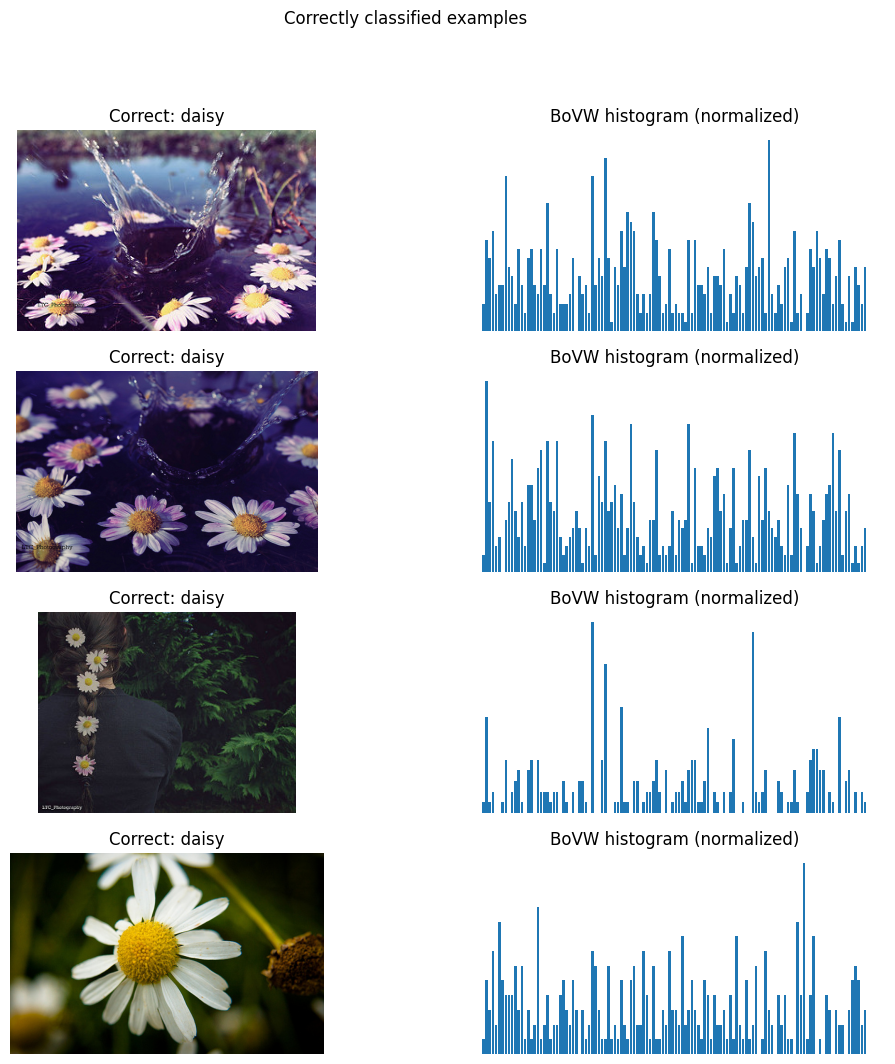

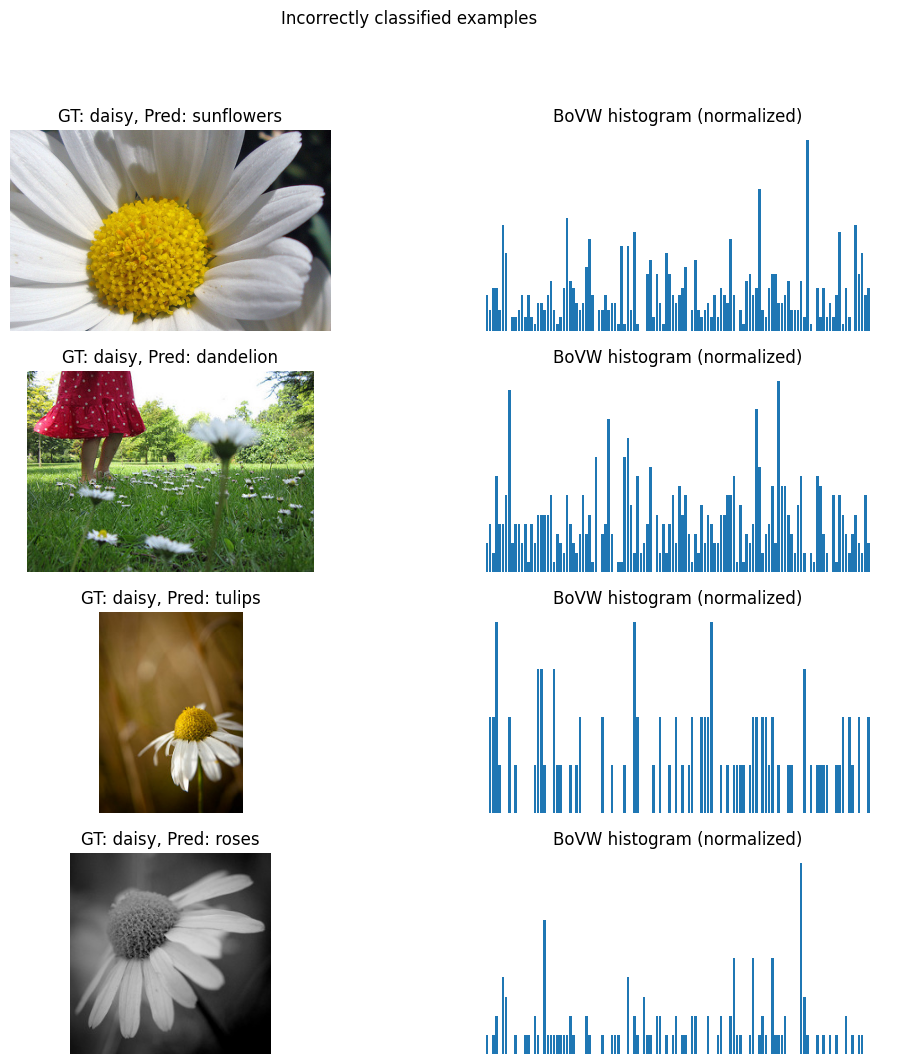

Saved kmeans, svm and label encoder to disk.


In [26]:
# Bag of Visual Words (BoVW) image classification pipeline
# Paste into Colab or Jupyter. Adjust dataset paths as needed.

import os
import glob
import random
from tqdm import tqdm
import numpy as np
import cv2
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler, normalize, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

# ---------- SETTINGS ----------
TRAIN_DIR = "Train"   # path to train folder containing subfolders per class
TEST_DIR  = "Test"    # path to test folder
USE_SIFT = True       # try SIFT, fallback to ORB if not available
N_CLUSTERS = 120      # number of visual words (vocabulary size) — tuneable (e.g., 50-500)
RANDOM_STATE = 42
MAX_DESCS_FOR_KMEANS = 100000  # limit descriptors for memory
# ------------------------------

# utility: read dataset (images and labels)
def load_image_paths(dataset_dir):
    classes = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir,d))])
    image_paths = []
    labels = []
    for cls in classes:
        files = glob.glob(os.path.join(dataset_dir, cls, "*"))
        files = [f for f in files if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))]
        for f in files:
            image_paths.append(f)
            labels.append(cls)
    return image_paths, labels, classes

# create feature extractor (SIFT if available, else ORB)
def make_extractor():
    if USE_SIFT:
        try:
            sift = cv2.SIFT_create()
            print("Using SIFT")
            return ("SIFT", sift)
        except Exception as e:
            print("SIFT not available, falling back to ORB:", e)
    # fallback ORB
    orb = cv2.ORB_create(nfeatures=1000)
    print("Using ORB")
    return ("ORB", orb)

# extract descriptors for an image (returns NxD or None)
def extract_descriptors(img_path, extractor):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    kind, ext = extractor
    if kind == "SIFT":
        kps, desc = ext.detectAndCompute(img, None)
        # desc is None if no keypoints
        return desc
    else: # ORB
        kps, desc = ext.detectAndCompute(img, None)
        # ORB returns uint8 descriptors; convert to float32 for kmeans
        if desc is not None:
            desc = desc.astype(np.float32)
        return desc

# Build descriptor list from training images
def gather_all_descriptors(image_paths, extractor, max_desc=MAX_DESCS_FOR_KMEANS):
    descriptors_list = []
    total = 0
    for p in tqdm(image_paths, desc="Extracting descriptors"):
        desc = extract_descriptors(p, extractor)
        if desc is None:
            continue
        descriptors_list.append(desc)
        total += desc.shape[0]
        if total > max_desc:
            break
    if len(descriptors_list) == 0:
        return None
    all_desc = np.vstack(descriptors_list)
    # If too many, subsample
    if all_desc.shape[0] > max_desc:
        idx = np.random.choice(all_desc.shape[0], max_desc, replace=False)
        all_desc = all_desc[idx]
    return all_desc

# Build codebook (k-means)
def build_codebook(descriptors, n_clusters=N_CLUSTERS):
    print(f"Clustering {descriptors.shape[0]} descriptors to {n_clusters} clusters ...")
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, batch_size=n_clusters*10, verbose=0)
    kmeans.fit(descriptors)
    return kmeans

# Compute BoVW histogram for a single image
def compute_bovw_histogram(desc, kmeans, n_clusters):
    hist = np.zeros(n_clusters, dtype=float)
    if desc is None or desc.shape[0] == 0:
        return hist
    labels = kmeans.predict(desc)
    for l in labels:
        hist[l] += 1.0
    # L1 or L2 normalization — we'll L2 normalize later using sklearn normalize
    return hist

# Convert dataset of image paths to BoVW matrix
def images_to_bovw(image_paths, extractor, kmeans, n_clusters):
    X = []
    descs_per_image = []
    for p in tqdm(image_paths, desc="Building histograms"):
        desc = extract_descriptors(p, extractor)
        hist = compute_bovw_histogram(desc, kmeans, n_clusters)
        X.append(hist)
        descs_per_image.append(None if desc is None else desc.shape[0])
    X = np.array(X, dtype=float)
    # L2 normalize each histogram
    X = normalize(X, norm='l2')
    return X, descs_per_image

# -------------------------------------------------------------------------
# Pipeline: load data, build codebook, compute histograms, train classifier
# -------------------------------------------------------------------------
# 1) load dataset paths
train_paths, train_labels, classes = load_image_paths(TRAIN_DIR)
test_paths, test_labels, _ = load_image_paths(TEST_DIR)

print("Classes:", classes)
print("Train samples:", len(train_paths), "Test samples:", len(test_paths))

# 2) create extractor
extractor = make_extractor()

# 3) gather descriptors from training images for kmeans
all_desc = gather_all_descriptors(train_paths, extractor)
if all_desc is None:
    raise RuntimeError("No descriptors found in training images. Check images and extractor.")

# 4) codebook via kmeans
kmeans = build_codebook(all_desc, n_clusters=N_CLUSTERS)

# 5) build BoVW histograms for train and test
X_train, train_desc_counts = images_to_bovw(train_paths, extractor, kmeans, N_CLUSTERS)
X_test, test_desc_counts = images_to_bovw(test_paths, extractor, kmeans, N_CLUSTERS)

# 6) encode labels
le = LabelEncoder()
y_train = le.fit_transform(train_labels)
y_test  = le.transform(test_labels)
print("Label classes (encoded):", dict(zip(le.classes_, range(len(le.classes_)))))

# 7) train classifier (Linear SVM)
clf = LinearSVC(random_state=RANDOM_STATE, max_iter=5000)
clf.fit(X_train, y_train)

# 8) predict
y_pred = clf.predict(X_test)

# 9) evaluation metrics
acc = accuracy_score(y_test, y_pred)
print("Accuracy on test set:", acc)

print("\nClassification Report (per-class precision/recall/F1):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

# Compute TPR and FPR per class from confusion matrix
TPR = []  # recall
FPR = []
for i in range(len(le.classes_)):
    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - TP - FP - FN
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    TPR.append(tpr)
    FPR.append(fpr)
    print(f"Class {le.classes_[i]}: TPR (Recall) = {tpr:.3f}, FPR = {fpr:.3f}")

# overall precision/recall/f1 averages already in classification_report
# also compute micro/macro F1 if you want:
from sklearn.metrics import f1_score
print("F1 (macro):", f1_score(y_test, y_pred, average='macro'))
print("F1 (micro):", f1_score(y_test, y_pred, average='micro'))

# 10) show qualitative results: some correct and incorrect examples
def show_examples(n=6):
    correct = []
    incorrect = []
    for p, gt, pred in zip(test_paths, y_test, y_pred):
        if gt == pred:
            correct.append((p, gt, pred))
        else:
            incorrect.append((p, gt, pred))
    # show first n correct and first n incorrect (if available)
    n_show = min(n, len(correct))
    plt.figure(figsize=(12, 3 * n_show))
    for i in range(n_show):
        p, gt, pred = correct[i]
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(n_show, 2, 2*i + 1); plt.imshow(img); plt.title(f"Correct: {le.classes_[gt]}"); plt.axis('off')
        plt.subplot(n_show, 2, 2*i + 2); plt.bar(range(N_CLUSTERS), X_test[test_paths.index(p)])
        plt.title("BoVW histogram (normalized)"); plt.axis('off')
    plt.suptitle("Correctly classified examples")
    plt.show()

    n_show = min(n, len(incorrect))
    plt.figure(figsize=(12, 3 * n_show))
    for i in range(n_show):
        p, gt, pred = incorrect[i]
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(n_show, 2, 2*i + 1); plt.imshow(img); plt.title(f"GT: {le.classes_[gt]}, Pred: {le.classes_[pred]}"); plt.axis('off')
        plt.subplot(n_show, 2, 2*i + 2); plt.bar(range(N_CLUSTERS), X_test[test_paths.index(p)])
        plt.title("BoVW histogram (normalized)"); plt.axis('off')
    plt.suptitle("Incorrectly classified examples")
    plt.show()

show_examples(n=4)

# Save model, kmeans and label encoder if you want for report
import joblib
joblib.dump(kmeans, "bovw_kmeans.joblib")
joblib.dump(clf, "bovw_svm.joblib")
joblib.dump(le, "label_encoder.joblib")
print("Saved kmeans, svm and label encoder to disk.")


